In [47]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np



In [48]:
path = '../data/raw/'
raw_products_data = pd.read_csv(f"{path}products.csv")
raw_product_variants_data =  pd.read_csv(f"{path}product_variants.csv")
raw_orders_data = pd.read_csv(f"{path}orders.csv")
raw_orders_items_data = pd.read_csv(f"{path}order_items.csv")

products = raw_products_data.copy(deep=True)
products_variants = raw_product_variants_data.copy(deep=True)
orders = raw_orders_data.copy(deep=True)
order_items = raw_orders_items_data.copy(deep=True)

### EDA - products

In [49]:
products.head()

,id,name,description,brand_id,category_id,ncm_code,unit_of_measure,is_active,created_at,updated_at
0,1,Motor de Popa 6014,Motor de popa 4 tempos para embarcações de lazer,9,9,50675645,UN,True,2023-06-07 05:32:02,2025-06-05 20:11:50
1,2,Vela Mestra 3870,Vela mestra em dacron para veleiros 32 pés,10,13,19180016,UN,True,2026-10-15 16:00:03,2026-11-01 00:37:26
2,3,Tinta Antifouling 5479,Tinta antiincrustante 3.6L para casco,4,4,26507166,L,True,2023-03-27 06:03:29,2026-09-11 04:08:29
3,4,Sonar Transducer 9933,Transdutor de sonar para profundidade,5,10,87920921,UN,True,2021-11-10 09:59:03,2023-05-05 18:50:45
4,5,Bússola de Bordo 3641,Bússola magnética líquida com iluminação,4,6,78779264,UN,True,2025-04-30 23:17:31,2026-08-29 06:22:16


In [50]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               500 non-null    int64
 1   name             500 non-null    str  
 2   description      490 non-null    str  
 3   brand_id         500 non-null    int64
 4   category_id      500 non-null    int64
 5   ncm_code         500 non-null    int64
 6   unit_of_measure  500 non-null    str  
 7   is_active        500 non-null    bool 
 8   created_at       500 non-null    str  
 9   updated_at       500 non-null    str  
dtypes: bool(1), int64(4), str(5)
memory usage: 35.8 KB


### Filtro e Limpeza do Produto Alvo

Nesta etapa, isolamos a base para manter apenas o produto desejado com o status **ativo**. Utilizamos o método `.loc[]` para aplicar as seguintes regras:

*   **TypeCasting:** Modificamos o tipo do atributo `created_at` para datetime, dessa forma podemos fazer as manipulações necessárias do tópico seguinte.
*   **Correção Temporal:** Filtramos os registros para manter apenas as criações feitas até a data atual, eliminando anomalias de "datas futuras" identificadas na base de origem.
*   **Drop de colunas:** Como o único propósito desta tabela nesta etapa é servir de ponte para o cruzamento com a tabela `product_variant`, mantemos apenas a coluna de `id`.

In [51]:
products['created_at'] = pd.to_datetime(products['created_at'])

products_clean = products.loc[
    (products["name"] == "Bússola de Bordo 702") & (products['is_active'] == True) & (products['created_at'] <= pd.Timestamp.today()), 
    ['id']
].copy()
products_clean


,id
73,74
239,240


### EDA - products_variant

In [52]:
products_variants.head()

,id,product_id,sku,barcode_ean,sale_price,cost_price,weight_kg,icms_rate,ipi_rate,is_active,created_at,updated_at
0,1,1,LHN-353137,8.123564e+11,2452.69,1409.59,17.466,18.0,5.0,True,2023-08-31 09:15:26,2026-07-29 01:56:22
1,2,1,LHN-424236,2.876605e+12,1057.68,482.96,38.900,18.0,10.0,True,2020-04-29 21:48:21,2024-03-30 05:43:11
2,3,1,LHN-680793,4.024713e+12,36.65,27.15,27.526,17.0,5.0,True,2024-02-03 07:46:25,2025-11-12 12:55:22
3,4,2,LHN-869444,6.530427e+12,2111.04,1486.65,10.215,12.0,10.0,True,2021-02-22 18:16:39,2025-07-20 13:19:23
4,5,2,LHN-152723,8.463512e+12,1425.34,662.95,32.302,12.0,0.0,True,2020-02-11 03:38:16,2025-06-20 12:14:15


In [53]:
products_variants.info()

<class 'pandas.DataFrame'>
RangeIndex: 1009 entries, 0 to 1008
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           1009 non-null   int64  
 1   product_id   1009 non-null   int64  
 2   sku          1009 non-null   str    
 3   barcode_ean  852 non-null    float64
 4   sale_price   1009 non-null   float64
 5   cost_price   1009 non-null   float64
 6   weight_kg    1009 non-null   float64
 7   icms_rate    1009 non-null   float64
 8   ipi_rate     1009 non-null   float64
 9   is_active    1009 non-null   bool   
 10  created_at   1009 non-null   str    
 11  updated_at   1009 non-null   str    
dtypes: bool(1), float64(6), int64(2), str(3)
memory usage: 87.8 KB


### Filtro, Limpeza e Tratamento das variantes

*   **TypeCasting:** Modificamos o tipo do atributo `created_at` para datetime, dessa forma podemos fazer as manipulações necessárias do tópico seguinte.
*   **Correção Temporal:** Filtramos os registros para manter apenas as criações feitas até a data atual, eliminando anomalias de "datas futuras" identificadas na base de origem.
*   **Drop de colunas:** Mantemos as colunas que são interessantes para o treinamento final (`sale_price`, `cost_price`, `weight_price`, `idade_em_dias`) e conexão com outras tabelas (id).
*   **Criação do atributo `idade_em_dias`:** Como os modelos preditivos não lidam corretamente com datas (seria lido como strings), fazemos a transformação para um valor númerico (dias). 

In [54]:
products_variants['created_at'] = pd.to_datetime(products_variants['created_at'])
products_variants = products_variants = products_variants[products_variants['created_at'] <= pd.Timestamp.today()].copy() 

products_variants

,id,product_id,sku,barcode_ean,sale_price,cost_price,weight_kg,icms_rate,ipi_rate,is_active,created_at,updated_at
0,1,1,LHN-353137,8.123564e+11,2452.69,1409.59,17.466,18.0,5.0,True,2023-08-31 09:15:26,2026-07-29 01:56:22
1,2,1,LHN-424236,2.876605e+12,1057.68,482.96,38.900,18.0,10.0,True,2020-04-29 21:48:21,2024-03-30 05:43:11
2,3,1,LHN-680793,4.024713e+12,36.65,27.15,27.526,17.0,5.0,True,2024-02-03 07:46:25,2025-11-12 12:55:22
3,4,2,LHN-869444,6.530427e+12,2111.04,1486.65,10.215,12.0,10.0,True,2021-02-22 18:16:39,2025-07-20 13:19:23
4,5,2,LHN-152723,8.463512e+12,1425.34,662.95,32.302,12.0,0.0,True,2020-02-11 03:38:16,2025-06-20 12:14:15
...,...,...,...,...,...,...,...,...,...,...,...,...
1004,1005,498,LHN-099784,6.107425e+12,1320.30,992.71,49.625,12.0,5.0,True,2025-11-08 10:33:50,2025-11-20 01:39:52
1005,1006,498,LHN-210485,3.139083e+12,2315.01,1429.02,22.589,12.0,10.0,False,2024-10-24 07:01:45,2026-08-12 01:38:14
1006,1007,499,LHN-556836,5.255542e+11,3154.28,1686.78,43.963,12.0,5.0,True,2024-03-30 17:13:23,2024-12-12 16:23:25
1007,1008,500,LHN-579323,NaN,3252.70,1498.94,17.295,17.0,5.0,True,2025-08-05 04:44:40,2025-12-10 13:18:08


In [55]:
df_products = pd.merge(products_clean, products_variants, left_on='id', right_on='product_id', how='inner')
df_products['idade_em_dias'] = (pd.Timestamp.today() - df_products['created_at']).dt.days

df_products = df_products[['id_y', 'sale_price', 'cost_price', 'weight_kg', 'idade_em_dias']].copy()
df_products = df_products.rename(columns={'id_y':'variant_id'})
df_products

,variant_id,sale_price,cost_price,weight_kg,idade_em_dias
0,148,1235.13,620.67,39.943,807
1,486,1758.87,950.74,7.955,1365


### EDA - order_items

In [56]:
order_items.head()

,id,order_id,product_variant_id,quantity,unit_price,icms_rate,ipi_rate,line_total
0,1,1,113,6,53.89,12.0,0.0,323.34
1,2,2,293,9,2398.41,17.0,10.0,21585.69
2,3,2,366,2,2697.71,17.0,10.0,5395.42
3,4,2,561,1,3757.73,18.0,0.0,3757.73
4,5,2,385,5,849.69,18.0,10.0,4248.45


In [57]:
order_items.info()

<class 'pandas.DataFrame'>
RangeIndex: 147320 entries, 0 to 147319
Data columns (total 8 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  147320 non-null  int64  
 1   order_id            147320 non-null  int64  
 2   product_variant_id  147320 non-null  int64  
 3   quantity            147320 non-null  int64  
 4   unit_price          147320 non-null  float64
 5   icms_rate           147320 non-null  float64
 6   ipi_rate            147320 non-null  float64
 7   line_total          147320 non-null  float64
dtypes: float64(4), int64(4)
memory usage: 9.0 MB


In [106]:
order_items.isnull().sum()

id                    0
order_id              0
product_variant_id    0
quantity              0
unit_price            0
icms_rate             0
ipi_rate              0
line_total            0
dtype: int64

### Merge e Seleção das colunas

Para esse data set não foi necessário fazer muitas mudanças, ele foi utilizado como ponte para podermos juntar as informações obtidas anteriormente com nosso dataset de vendas.

In [58]:
df_orders = pd.merge(df_products, order_items, left_on='variant_id', right_on='product_variant_id', how='inner')
id_variante = df_orders[['variant_id']].copy() # mantemos salvo o id das variantes para poder fazer uma analise detalhada mais tarde
df_orders = df_orders[['order_id','quantity', 'unit_price', 'sale_price', 'cost_price', 'weight_kg', 'idade_em_dias']].copy()
df_orders

,order_id,quantity,unit_price,sale_price,cost_price,weight_kg,idade_em_dias
0,150,2,1235.13,1235.13,620.67,39.943,807
1,397,7,1235.13,1235.13,620.67,39.943,807
2,563,1,1235.13,1235.13,620.67,39.943,807
3,576,2,1235.13,1235.13,620.67,39.943,807
4,599,2,1235.13,1235.13,620.67,39.943,807
...,...,...,...,...,...,...,...
308,48402,5,1758.87,1758.87,950.74,7.955,1365
309,49247,3,1758.87,1758.87,950.74,7.955,1365
310,49308,5,1758.87,1758.87,950.74,7.955,1365
311,49338,10,1758.87,1758.87,950.74,7.955,1365


### EDA - orders

In [59]:
orders.head()

,id,order_number,channel,customer_id,salesperson_id,location_id,status,subtotal,discount_amount,total,placed_at,created_at,updated_at
0,1,SO-000001,ecommerce,1136,NaN,1,paid,323.34,35.57,287.77,2022-09-06 05:37:37,2022-09-06 05:37:37,2022-09-06 05:37:37
1,2,SO-000002,ecommerce,618,9.0,4,paid,53199.05,0.00,53199.05,2023-02-03 04:36:21,2023-02-03 04:36:21,2023-02-03 04:36:21
2,3,SO-000003,pos,227,10.0,4,confirmed,17157.39,0.00,17157.39,2024-12-30 07:15:17,2024-12-30 07:15:17,2024-12-30 07:15:17
3,4,SO-000004,ecommerce,1123,NaN,3,paid,11095.62,665.74,10429.88,2024-03-12 20:39:36,2024-03-12 20:39:36,2024-03-12 20:39:36
4,5,SO-000005,ecommerce,426,9.0,2,confirmed,32842.03,0.00,32842.03,2020-03-27 13:52:12,2020-03-27 13:52:12,2020-03-27 13:52:12


In [107]:
orders.isnull().sum()

id                     0
order_number           0
channel                0
customer_id            0
salesperson_id     24131
location_id            0
status                 0
subtotal               0
discount_amount        0
total                  0
placed_at              0
created_at             0
updated_at             0
dtype: int64

### Filtro, Limpeza e Tratamento

*   **TypeCasting:** Modificamos o tipo do atributo `placed_at` para datetime, dessa forma podemos fazer as manipulações necessárias do tópico seguinte.
*   **Correção Temporal:** Filtramos os registros para manter apenas os pedidos feitos até a data atual, eliminando anomalias de "datas futuras" identificadas na base de origem.
*   **Drop de colunas:** Mantemos as colunas que são interessantes para o treinamento final.
*   **Criação dos atributo `year`, `month` e `trimestre_venda`:** Esses valores serão necessários para o modelo poder fazer a previsão do primeiro trimestre de 2026.
*   **Criação de Dummies:** Convertemos as colunas channel e location_id em múltiplas colunas numéricas binárias (0 e 1). Essa conversão é necessária pois o algoritmo de machine learning não processa variáveis textuais. Mesmo location_id sendo uma coluna númerica, fazemos a conversão para o algoritmo não interpretar os id's com uma lógica hierárquica (dando um peso inexistente para o id).
*   **Criação das variáveis x e y:** Separamos os dados para treinamento (modelo_x) e os dados alvo (modelo_y). 

In [62]:
orders['placed_at'] = pd.to_datetime(orders['placed_at'])
orders_paid = orders[(orders['status']=='paid') & (orders['placed_at'] <= pd.Timestamp.today())].copy()
orders_paid['year'] = orders_paid['placed_at'].dt.year
orders_paid['month'] = orders_paid['placed_at'].dt.month
orders_paid['trimestre_venda'] = orders['placed_at'].dt.quarter
df_final = pd.merge(df_orders, orders_paid, left_on='order_id', right_on='id',how='inner')
df_final = df_final[['location_id','channel','quantity', 'unit_price', 'sale_price', 'cost_price','discount_amount','weight_kg','year','month','trimestre_venda','idade_em_dias']].copy()
df_final = pd.get_dummies(df_final, columns=['channel','location_id'])
df_final

,quantity,unit_price,sale_price,cost_price,discount_amount,weight_kg,year,month,trimestre_venda,idade_em_dias,channel_ecommerce,channel_pos,location_id_1,location_id_2,location_id_3,location_id_4,location_id_5,location_id_6
0,2,1235.13,1235.13,620.67,0.00,39.943,2025,1,1,807,False,True,False,False,False,True,False,False
1,7,1235.13,1235.13,620.67,0.00,39.943,2020,2,1,807,True,False,False,False,False,False,True,False
2,1,1235.13,1235.13,620.67,0.00,39.943,2024,3,1,807,False,True,False,False,False,True,False,False
3,2,1235.13,1235.13,620.67,345.84,39.943,2024,2,1,807,False,True,False,False,True,False,False,False
4,2,1235.13,1235.13,620.67,0.00,39.943,2025,7,3,807,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,3,1758.87,1758.87,950.74,0.00,7.955,2025,2,1,1365,True,False,False,False,False,False,True,False
199,5,1758.87,1758.87,950.74,0.00,7.955,2023,9,3,1365,True,False,False,False,False,False,False,True
200,3,1758.87,1758.87,950.74,0.00,7.955,2026,1,1,1365,False,True,False,False,True,False,False,False
201,5,1758.87,1758.87,950.74,0.00,7.955,2020,12,4,1365,True,False,False,True,False,False,False,False


### Verificação de valores excessivos

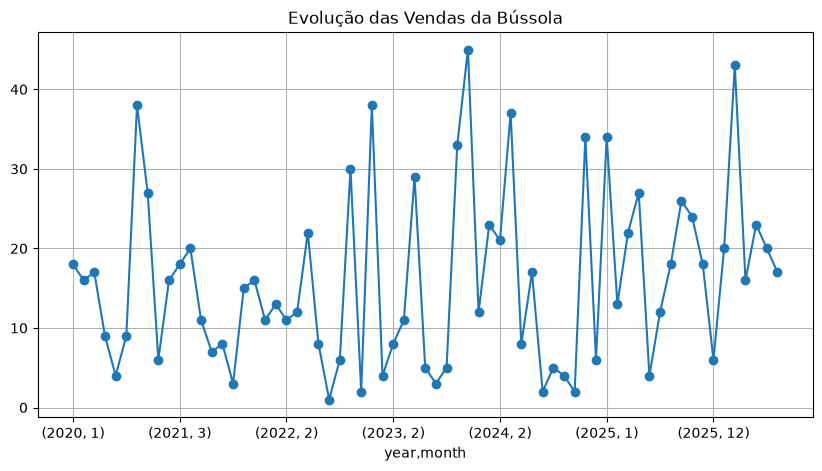

In [105]:
vendas_por_mes = df_final.groupby(['year', 'month'])['quantity'].sum()

vendas_por_mes.plot(kind='line', marker='o', figsize=(10, 5))
plt.title('Evolução das Vendas da Bússola')
plt.grid(True)
plt.show()

### Criação do Baseline (média movel)

In [ ]:
'''
Baseline: é um ponto de partida simples e sem complexidade usado para comparar e medir o ganho de desempenho de modelos de inteligência artificial ou machine learning mais avançados
'''

df_2025 = df_final[df_final['year'] == 2025]

df_ultimo_periodo = df_2025[df_2025['month'].isin([7,8,9,10,11,12])] 
df_ultimo_periodo = df_ultimo_periodo.groupby('month')['quantity'].sum()
media_movel_2025 = df_ultimo_periodo.rolling(window=3).mean()
media_movel_2025 = media_movel_2025[media_movel_2025.index >= 10]
media_movel_2025

month
10    22.666667
11    22.666667
12    16.000000
Name: quantity, dtype: float64

In [100]:
m_2025_list = media_movel_2025.tolist()
meses_previsao = [1, 2, 3]
previsao_2026 = []

for mes in meses_previsao:
    ultimos_3_meses = m_2025_list[-3:]
    previsao = sum(ultimos_3_meses) / 3
    m_2025_list.append(previsao)

    previsao_2026.append({
            'mes': mes,
            'previsao': round(previsao)
    })

df_previsoes = pd.DataFrame(previsao_2026)

df_previsoes


,mes,previsao
0,1,20
1,2,20
2,3,19


#### Treinamento do modelo com DecisionTreeRegressor e RandomForestRegressor

In [88]:
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error 

In [89]:
'''
DecisionTreeRegressor(random_state=42) instância o algoritmo. O parametro state_random faz com que o algoritmo sempre começa sua aleatoriedade do mesmo valor (dessa forma é possível analisar
se houve melhora no algoritmo)
'''

def get_DecisionTreeRegressor_model(train_X, train_y):
    dtree = DecisionTreeRegressor(random_state=1) 
    dtree.fit(train_X, train_y) 
    return dtree

In [90]:
def get_RandomForest_model(train_X, train_y):
    forest_model = RandomForestRegressor(random_state=1)
    forest_model.fit(train_X, train_y)
    return forest_model

In [91]:
'''Para evitar o data lakage fazemos a separação dos dados de forma manual ao invés de utilizar o train_test_split da biblioteca'''
treino = df_final[df_final['year'] <= 2025].copy()
teste = df_final[(df_final['year'] == 2026) & (df_final['month'].isin([1, 2, 3]))].copy()

In [92]:
'''Dados de treino (até o final de 2025)'''
train_y = treino['quantity']
train_X = treino.drop(columns=['quantity'])

In [93]:
'''Valores que queremos prever (primeiro trimestre de 2026)'''
val_y = teste['quantity']
val_X = teste.drop(columns=['quantity'])

In [ ]:
'''armazena o algoritmo treinado'''
model_dtree = get_DecisionTreeRegressor_model(train_X, train_y) 
model_rforest = get_RandomForest_model(train_X, train_y) 

'''predict() faz com que o algoritmo tente prever os valores do primeiro trimestre de 2026'''
dtree_prediction = model_dtree.predict(val_X) 
rforest_prediction = model_rforest.predict(val_X)

'''
Cálcula a diferença média entre as vendas reais do primeiro trimestre de 2026 (val_y) com o que o algoritmo preveu (dtree_prediction/rforest_prediction).
Dessa forma vemos qual o algoritmo mais inteligente.
'''
print("Erro Árvore de Decisão (MAE):", mean_absolute_error(val_y, dtree_prediction))
print("Erro Random Forest (MAE):", mean_absolute_error(val_y, rforest_prediction))

Erro Árvore de Decisão (MAE): 3.6842105263157894
Erro Random Forest (MAE): 3.124166666666666


In [102]:
'''
Cria uma tabela com os valores reais e as previsoes 
| mes | vendas_reais | previsao |
'''
tb_rforest = val_X[['month']].copy()
tb_rforest['vendas_reais'] = val_y
tb_rforest['previsao'] = rforest_prediction

'''
    Faz um resumo mensal (base mensal pedida na regra da questão)
'''
tb_rforest_mensal = tb_rforest.groupby('month').sum()

'''
Tira a média do erro entre as vendas reais e as previsões (média de quantas unidades errou)
'''
mae_rf_mensal = mean_absolute_error(tb_rforest_mensal['vendas_reais'], tb_rforest_mensal['previsao'])
mae_baseline = mean_absolute_error(tb_rforest_mensal['vendas_reais'], df_previsoes['previsao'])

print(f"MAE Random Forest: {mae_rf_mensal}")
print(f"MAE baseline: {mae_baseline}")

tb_rforest_mensal


MAE Random Forest: 7.239722222222223
MAE baseline: 8.666666666666666


,vendas_reais,previsao
month,,
1,20,27.190000
2,43,41.196667
3,16,28.725833


### Utilizando seu modelo treinado, qual é a soma total da previsão de vendas (arredondada para número inteiro) para o 'Bússola de Bordo 702' durante o primeiro trimestre de 2026?

In [96]:
print(tb_rforest_mensal['previsao'].sum().round().astype(int))


97
